# Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

## Загрузка и первичный осмотр данных

На первом этапе загружается датасет и проводится его первичный анализ: изучаются размер таблицы, названия столбцов, типы данных, наличие пропусков и дубликатов. Это необходимо, чтобы понять структуру данных и определить дальнейшие шаги предобработки.

In [6]:
data_path_local = "student_lifestyle_100k.csv"
data_path_kaggle = "/kaggle/input/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data/student_lifestyle_100k.csv"

try:
    df = pd.read_csv(data_path_local)
except FileNotFoundError:
    df = pd.read_csv(data_path_kaggle)

df_raw = df.copy()
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [7]:
print("Размер датасета:", df.shape)
print("Названия столбцов:", df.columns.tolist(), sep='\n')

Размер датасета: (100000, 11)
Названия столбцов:
['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [9]:
df.describe(include="all")

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,50120,20071,NaN,NaN,NaN,NaN,NaN,NaN,89938
mean,51000.500000,21.009010,NaN,NaN,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,NaN
std,28867.657797,2.000382,NaN,NaN,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,NaN
min,1001.000000,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,26000.750000,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,51000.500000,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,76000.250000,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


In [10]:
print("Типы данных:")
display(df.dtypes)

Типы данных:


Student_ID              int64
Age                     int64
Gender                    str
Department                str
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object

### Проверка типов данных

Перед дальнейшим анализом были проверены типы данных всех столбцов. Числовые признаки распознаны как числовые, категориальные — как категориальные. Дополнительного преобразования типов не потребовалось.

Также отдельно была выполнена проверка на полные дубликаты, чтобы убедиться, что в таблице нет повторяющихся наблюдений, способных исказить статистики и качество моделей.

In [11]:
# Пропуски
display(df.isnull().sum())
# Дубликаты
print("Количество дубликатов:", df.duplicated().sum())

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Количество дубликатов: 0


### Обработка пропусков

После проверки было установлено, что пропущенные значения в датасете отсутствуют. Тем не менее, при подготовке данных для обучения использовалась стандартная схема обработки: для числовых признаков — заполнение медианой, для категориальных — наиболее частым значением.

Такой подход выбран потому, что медиана устойчивее к выбросам, а заполнение модой является базовым и интерпретируемым решением для категориальных признаков.

In [12]:
number_cols = df.select_dtypes(include=np.number).columns.tolist()
category_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Числовые признаки:", number_cols)
print("Категориальные признаки:", category_cols)

Числовые признаки: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Категориальные признаки: ['Gender', 'Department', 'Depression']


## 2. Разведочный анализ данных (EDA)

На этапе EDA исследуются распределения признаков, проверяются возможные выбросы, анализируются категориальные переменные и визуально изучаются связи между признаками и целевыми переменными. Цель этого этапа — лучше понять данные и найти возможные проблемы до обучения моделей.

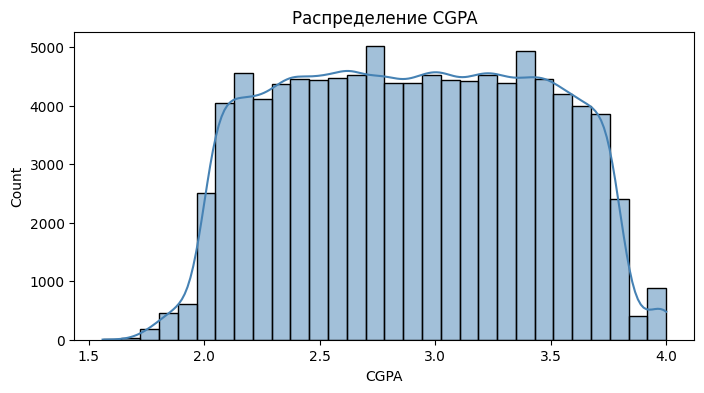

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df["CGPA"], bins=30, kde=True, color="steelblue")
plt.title("Распределение CGPA")
plt.show()

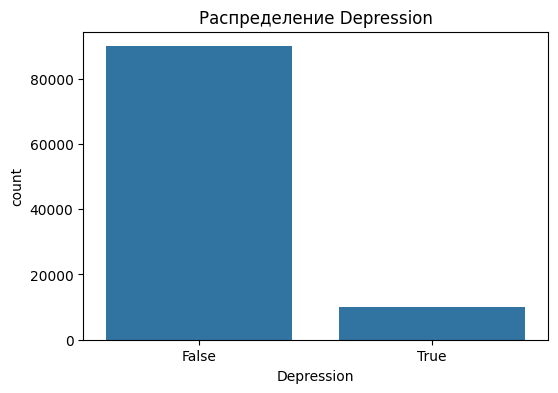

Доли классов Depression:


Depression
False    0.89938
True     0.10062
Name: proportion, dtype: float64

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Depression")
plt.title("Распределение Depression")
plt.show()

print("Доли классов Depression:")
display(df["Depression"].value_counts(normalize=True))

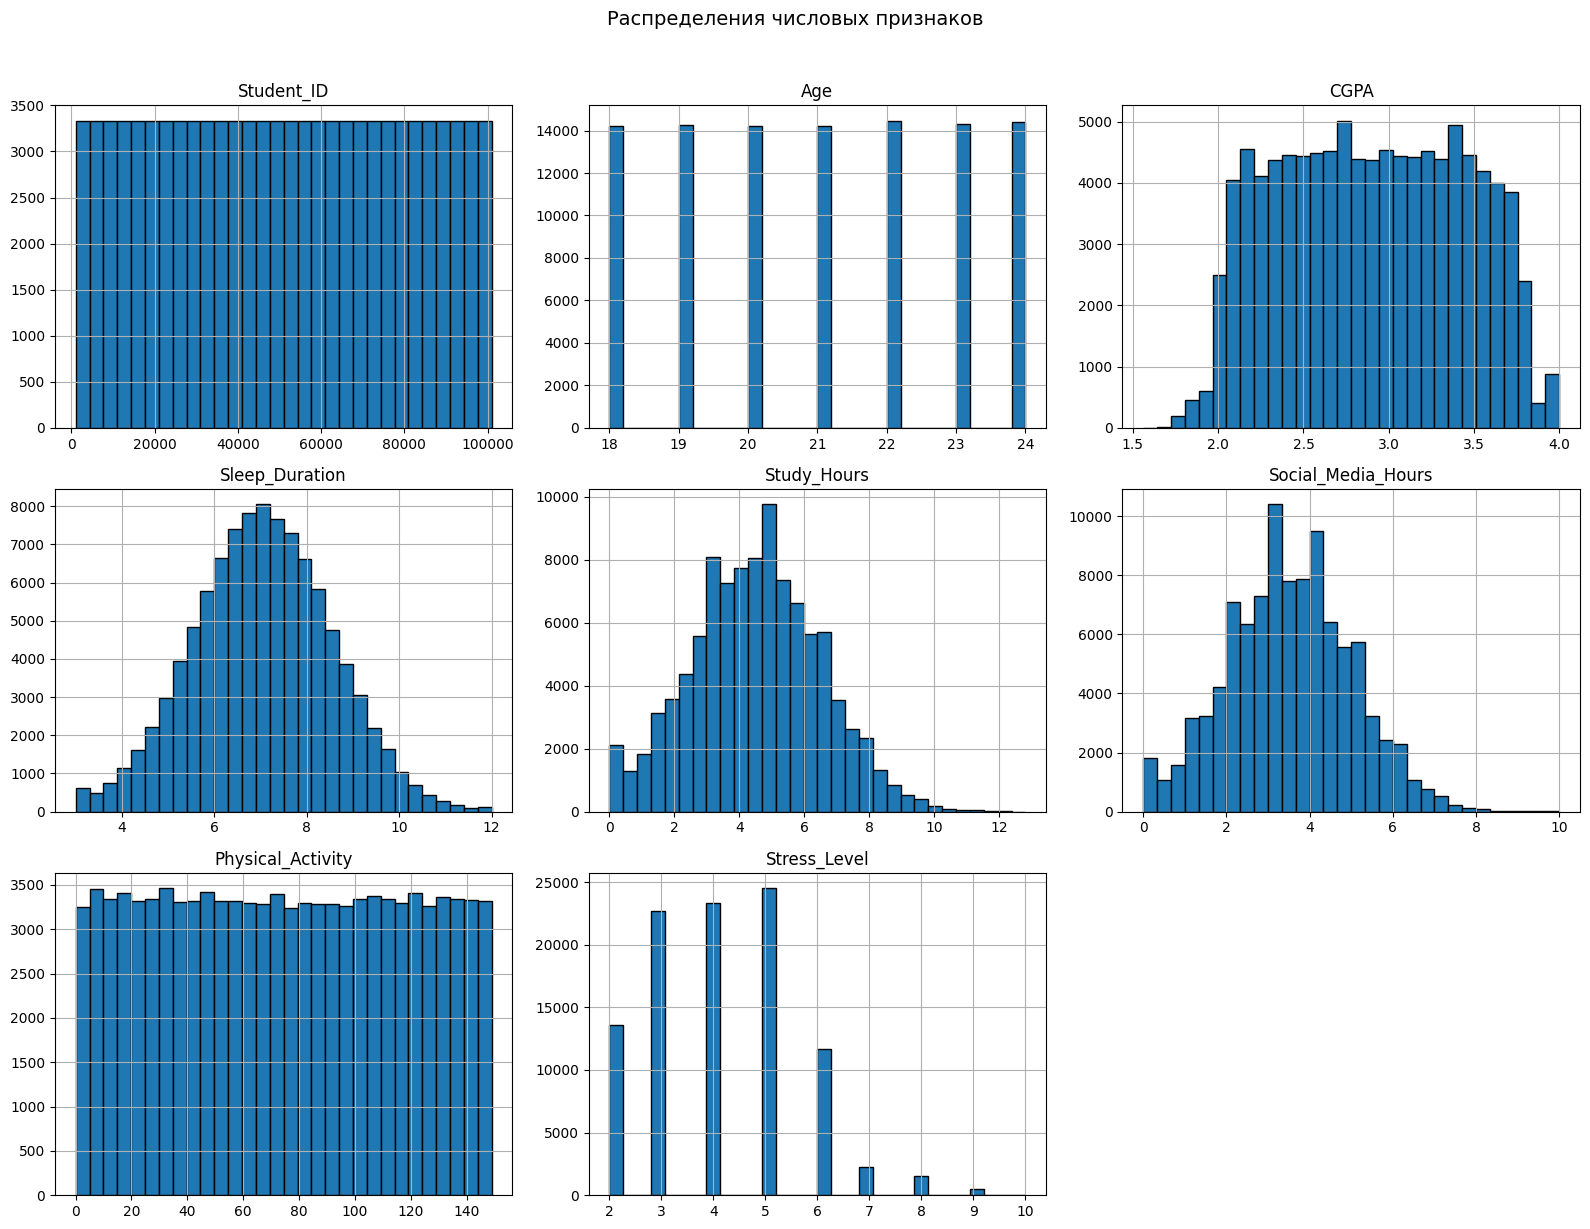

In [15]:
df[number_cols].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Распределения числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

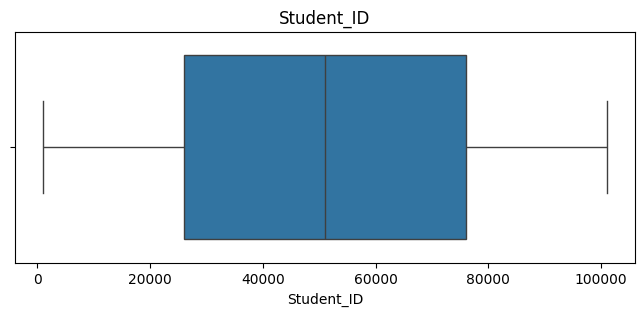

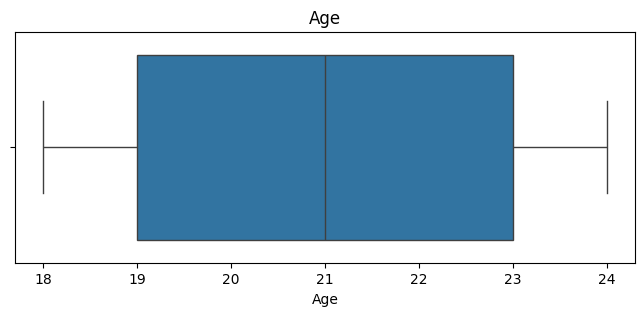

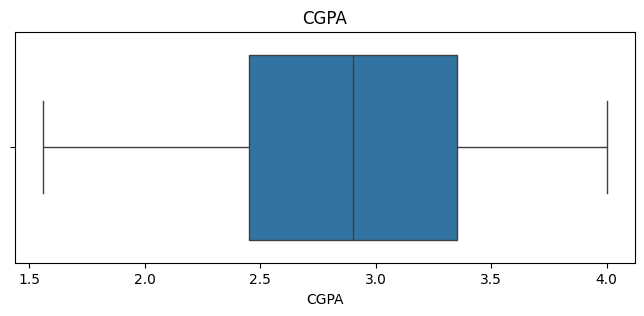

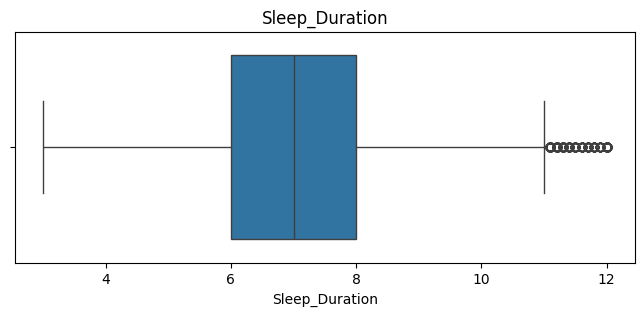

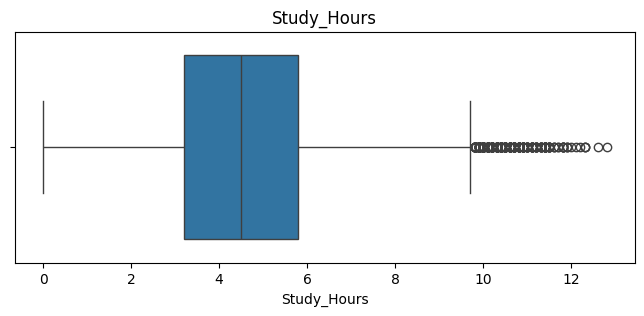

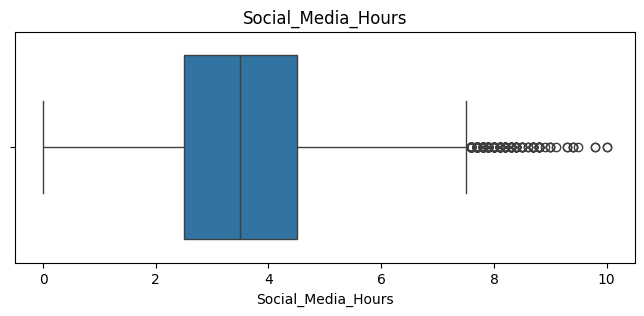

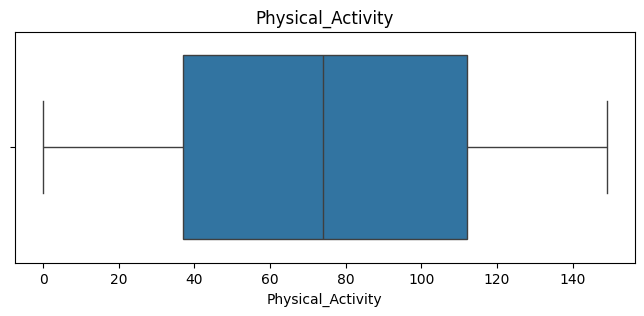

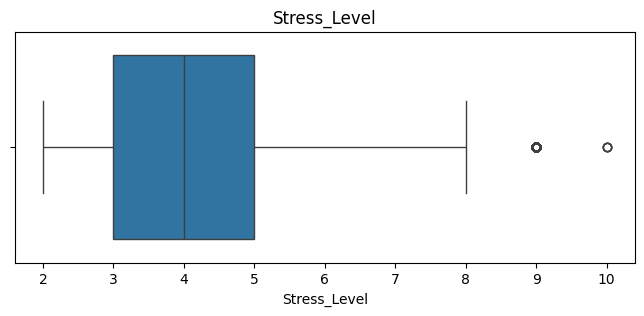

In [16]:
for col in number_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

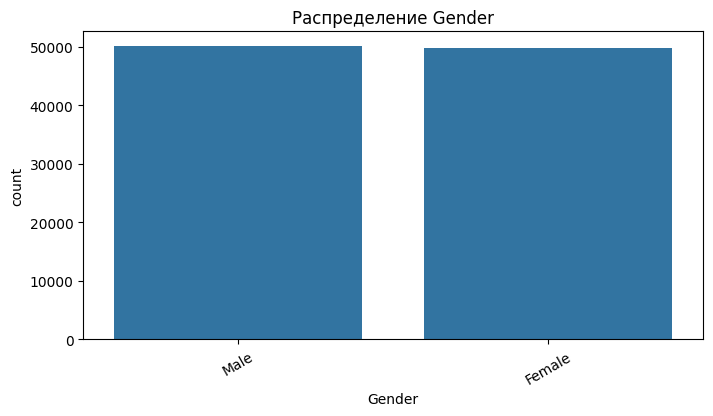

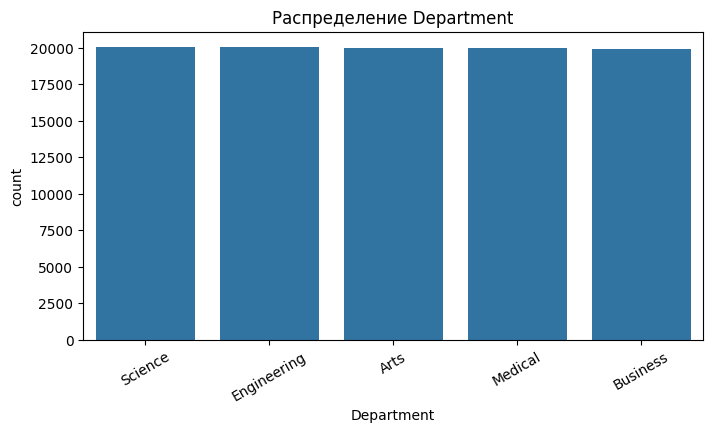

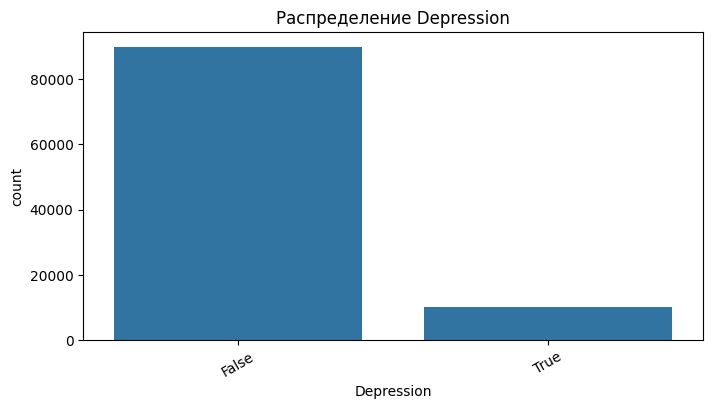

In [17]:
for col in category_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Распределение {col}")
    plt.xticks(rotation=30)
    plt.show()

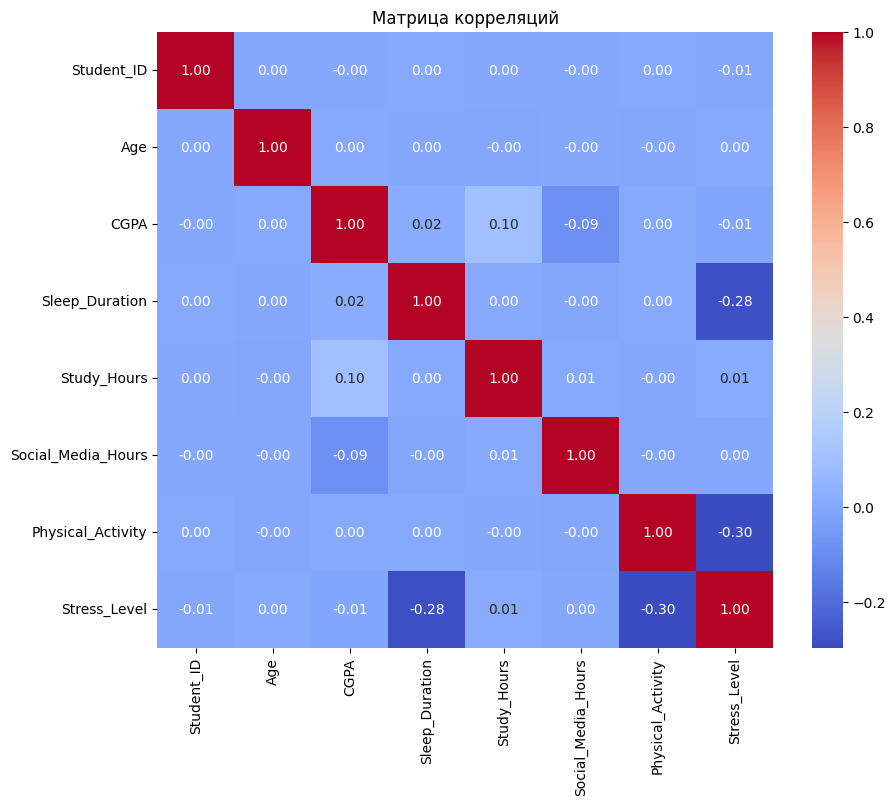

In [18]:
plt.figure(figsize=(10, 8))
corr_matrix = df[number_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций")
plt.show()

## Связь признаков с CGPA

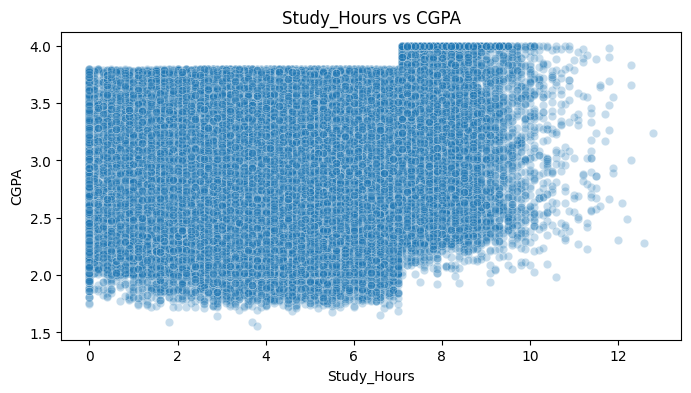

In [19]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Study_Hours", y="CGPA", alpha=0.25)
plt.title("Study_Hours vs CGPA")
plt.show()

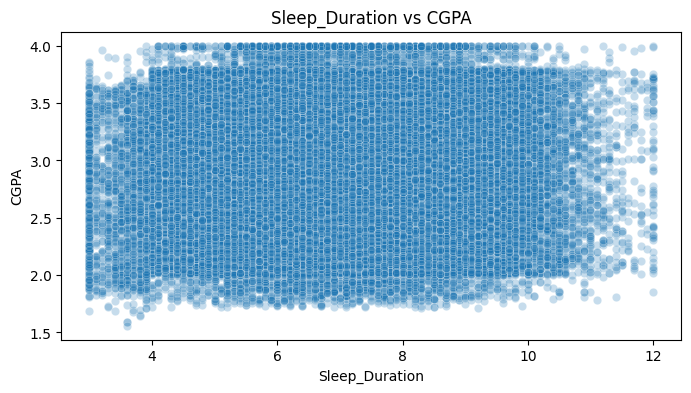

In [20]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Sleep_Duration", y="CGPA", alpha=0.25)
plt.title("Sleep_Duration vs CGPA")
plt.show()

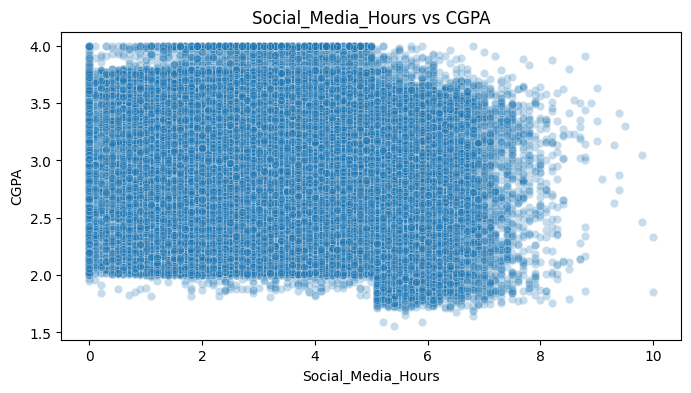

In [21]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Social_Media_Hours", y="CGPA", alpha=0.25)
plt.title("Social_Media_Hours vs CGPA")
plt.show()

## Связь признаков с Depression

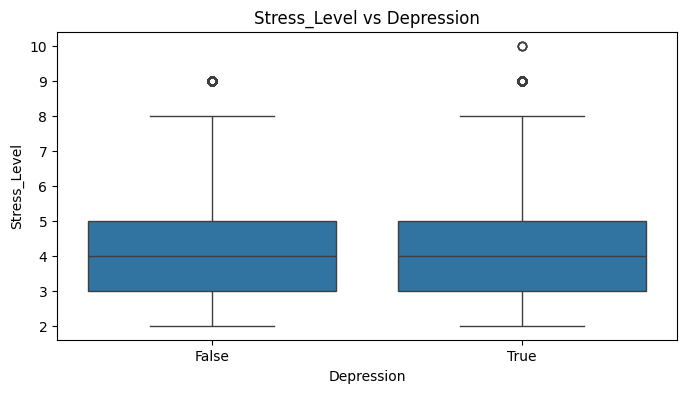

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Depression", y="Stress_Level")
plt.title("Stress_Level vs Depression")
plt.show()

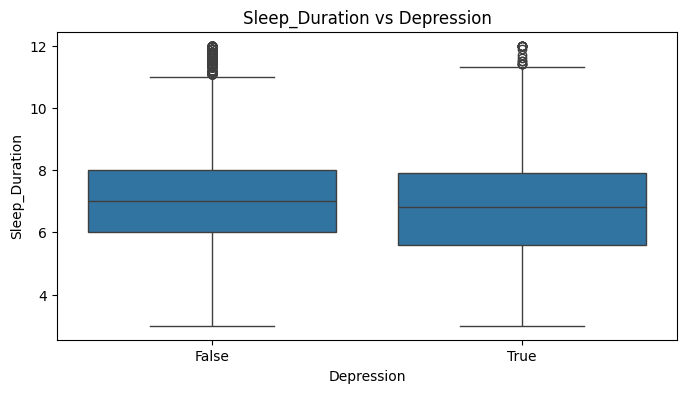

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Depression", y="Sleep_Duration")
plt.title("Sleep_Duration vs Depression")
plt.show()

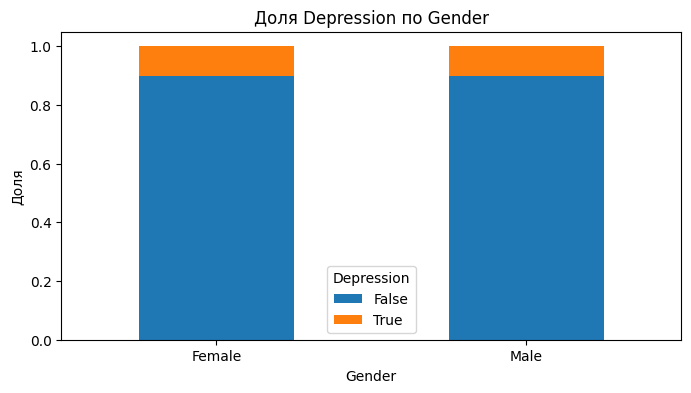

In [24]:
gender_dep = pd.crosstab(df["Gender"], df["Depression"], normalize="index")
gender_dep.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.title("Доля Depression по Gender")
plt.ylabel("Доля")
plt.xticks(rotation=0)
plt.show()

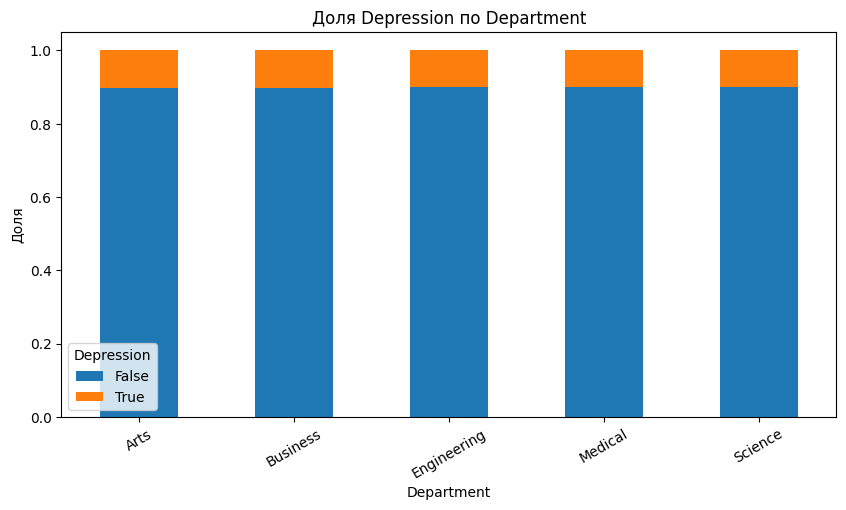

In [25]:
dept_dep = pd.crosstab(df["Department"], df["Depression"], normalize="index")
dept_dep.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Доля Depression по Department")
plt.ylabel("Доля")
plt.xticks(rotation=30)
plt.show()

### Выводы по EDA

В ходе разведочного анализа были изучены размер датасета, типы признаков, базовые статистики, распределения числовых и категориальных переменных, наличие выбросов, а также взаимосвязи между признаками и целевыми переменными.

В результате анализа было установлено следующее:

* пропущенные значения в датасете отсутствуют;
* полные дубликаты отсутствуют;
* признак Student_ID является техническим идентификатором и не несёт полезной информации для обучения модели;
* числовые признаки в целом имеют реалистичные диапазоны значений;
* по boxplot-графикам наблюдаются отдельные выбросы прежде всего в признаках Sleep_Duration, Study_Hours, Social_Media_Hours и Stress_Level, однако они выглядят как редкие, но возможные наблюдения, а не как явные ошибки данных;
* распределение целевой переменной CGPA является корректным и подходит для задачи регрессии;
* целевая переменная Depression имеет выраженный дисбаланс классов: большинство наблюдений относится к классу False, а класс True составляет меньшую долю;
* распределения категориальных признаков Gender и Department выглядят сбалансированными;
* сильной мультиколлинеарности между числовыми признаками не обнаружено;
* между признаками образа жизни и целевыми переменными наблюдаются только слабые зависимости: для CGPA заметна слабая положительная связь с Study_Hours и слабая отрицательная связь с Social_Media_Hours, а для Depression наиболее заметной выглядит связь с уровнем стресса, хотя различия между группами в целом не являются резкими.

На основе EDA было принято решение:

* удалить из обучающей выборки неинформативный признак Student_ID;
* сохранить редкие экстремальные значения под контролем и при необходимости дополнительно проверить их влияние на качество моделей;
* закодировать категориальные признаки;
* масштабировать числовые признаки перед обучением моделей;
* проверить, улучшают ли engineered-признаки качество моделей по сравнению с базовым набором признаков.


## 3. Проверка качества данных и предобработка

После разведочного анализа выполняется проверка логических аномалий и подготовка данных к моделированию. На этом этапе удаляются неинформативные признаки, исключаются некорректные наблюдения и создаются дополнительные признаки, которые могут быть полезны для моделей.

In [26]:
print("Age < 0:", (df["Age"] < 0).sum())
print("Sleep_Duration < 0:", (df["Sleep_Duration"] < 0).sum())
print("Study_Hours < 0:", (df["Study_Hours"] < 0).sum())
print("Social_Media_Hours < 0:", (df["Social_Media_Hours"] < 0).sum())
print("Physical_Activity < 0:", (df["Physical_Activity"] < 0).sum())
print("Stress_Level < 0:", (df["Stress_Level"] < 0).sum())

Age < 0: 0
Sleep_Duration < 0: 0
Study_Hours < 0: 0
Social_Media_Hours < 0: 0
Physical_Activity < 0: 0
Stress_Level < 0: 0


In [27]:
print("Sleep_Duration > 24:", (df["Sleep_Duration"] > 24).sum())
print("Study_Hours > 24:", (df["Study_Hours"] > 24).sum())
print("Social_Media_Hours > 24:", (df["Social_Media_Hours"] > 24).sum())
print("Physical_Activity > 24:", (df["Physical_Activity"] > 24 * 60).sum())

Sleep_Duration > 24: 0
Study_Hours > 24: 0
Social_Media_Hours > 24: 0
Physical_Activity > 24: 0


In [ ]:
df["Physical_Activity_Hours"] = df["Physical_Activity"] / 60

df["Total_Daily_Load"] = (
    df["Sleep_Duration"]
    + df["Study_Hours"]
    + df["Social_Media_Hours"]
    + df["Physical_Activity_Hours"]
)

invalid_mask = df["Total_Daily_Load"] > 24

print("Количество подозрительных строк:", invalid_mask.sum())
print("Доля подозрительных строк (%):", round(invalid_mask.mean() * 100, 4))

display(
    df.loc[
        invalid_mask,
        [
            "Student_ID",
            "Sleep_Duration",
            "Study_Hours",
            "Social_Media_Hours",
            "Physical_Activity",
            "Physical_Activity_Hours",
            "Total_Daily_Load"
        ]
    ].head(10)
)

Количество подозрительных строк: 478
Доля подозрительных строк (%): 0.478


,Student_ID,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Physical_Activity_Hours,Total_Daily_Load
1228,2229,10.2,7.9,7.1,133,2.216667,27.416667
1412,2413,9.3,7.6,4.8,140,2.333333,24.033333
1449,2450,9.0,9.1,5.2,97,1.616667,24.916667
1551,2552,9.1,6.1,7.1,116,1.933333,24.233333
1714,2715,9.0,9.5,3.3,134,2.233333,24.033333
1991,2992,7.3,7.8,7.6,123,2.050000,24.750000
2178,3179,8.0,11.5,3.0,104,1.733333,24.233333
2190,3191,10.7,5.5,6.6,88,1.466667,24.266667
2222,3223,9.5,10.4,5.8,107,1.783333,27.483333
2524,3525,8.8,8.8,6.5,23,0.383333,24.483333


In [29]:
df = df.loc[~invalid_mask].copy()

print("Размер датасета после удаления подозрительных строк:", df.shape)
print("Осталось строк с Total_Daily_Load > 24:", (df["Total_Daily_Load"] > 24).sum())

Размер датасета после удаления подозрительных строк: (99522, 13)
Осталось строк с Total_Daily_Load > 24: 0


In [30]:
def cap_outliers_iqr(df, columns):
    df = df.copy()
    clip_counts = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        before = df[col].copy()
        df[col] = df[col].clip(lower, upper)
        clip_counts[col] = int((before != df[col]).sum())
    return df, clip_counts

outlier_cols = ["Age", "Study_Hours", "Sleep_Duration", "Social_Media_Hours", "Physical_Activity", "Stress_Level", "CGPA"]
df, clip_counts = cap_outliers_iqr(df, outlier_cols)

clip_counts_df = pd.DataFrame({
    "feature": list(clip_counts.keys()),
    "clipped_values_count": list(clip_counts.values())
}).sort_values(by="clipped_values_count", ascending=False)

display(clip_counts_df)


,feature,clipped_values_count
5,Stress_Level,478
2,Sleep_Duration,333
1,Study_Hours,308
3,Social_Media_Hours,283
0,Age,0
4,Physical_Activity,0
6,CGPA,0


### Коррекция выбросов

Для числовых признаков была применена коррекция выбросов методом IQR. Вместо удаления всех выбросов использовалось ограничение значений по нижней и верхней границе. Такой подход позволяет уменьшить влияние экстремальных значений на модели и при этом не терять слишком много наблюдений.

Наибольшая коррекция потребовалась для `Stress_Level` (478 значений), `Sleep_Duration` (333), `Study_Hours` (308) и `Social_Media_Hours` (283). Для `Age`, `Physical_Activity` и `CGPA` заметной коррекции не потребовалось.


### Логическая проверка согласованности данных

Для каждого наблюдения была выполнена логическая проверка: рассчитана суммарная занятость студента в течение суток как сумма продолжительности сна, времени учёбы, времени в социальных сетях и физической активности. Поскольку физическая активность задана в минутах, перед расчётом она была переведена в часы.  

Наблюдения, в которых суммарная нагрузка превышала 24 часа в сутки, были признаны логически подозрительными и исключены из датасета.

In [31]:
df = df.drop(columns=["Student_ID"])
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Physical_Activity_Hours,Total_Daily_Load
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,1.900000,15.900000
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,2.366667,21.066667
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,2.283333,11.783333
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,2.166667,16.866667
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,0.066667,13.766667


### Удаление неинформативного признака

Столбец `Student_ID` был удалён из датасета, так как он является идентификатором объекта и не несёт содержательной информации для предсказания целевых переменных.

In [32]:
df_before_fe = df.copy()

df["Study_Sleep_Ratio"] = df["Study_Hours"] / (df["Sleep_Duration"] + 1e-6)
df["Stress_Social_Interaction"] = df["Stress_Level"] * df["Social_Media_Hours"]
df["Activity_Sleep_Balance"] = df["Physical_Activity_Hours"] / (df["Sleep_Duration"] + 1e-6)

df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Physical_Activity_Hours,Total_Daily_Load,Study_Sleep_Ratio,Stress_Social_Interaction,Activity_Sleep_Balance
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,1.900000,15.900000,0.452055,17.0,0.260274
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,2.366667,21.066667,1.309091,12.0,0.430303
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,2.283333,11.783333,0.425926,5.4,0.422839
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,2.166667,16.866667,0.246914,13.8,0.267490
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,0.066667,13.766667,0.382353,25.8,0.009804


### Создание новых признаков

В рамках feature engineering были созданы дополнительные признаки, которые могут лучше описывать образ жизни студента:
- отношение учебной нагрузки ко сну;
- совместное влияние уровня стресса и времени в социальных сетях;
- баланс физической активности и сна.

Такие признаки позволяют проверить, даст ли комбинация исходных переменных лучший результат, чем использование только исходных данных.

## 4. Задача регрессии: предсказание CGPA

Для задачи регрессии в качестве целевой переменной был выбран признак `CGPA`.  
В качестве модели используется `Linear Regression`.  
Качество модели оценивается по метрикам MAE, MSE, RMSE и R².


In [33]:
target_reg = "CGPA"

X_reg = df.drop(columns=[target_reg, "Depression"])
y_reg = df[target_reg]

print(X_reg.shape, y_reg.shape)

(99522, 13) (99522,)


In [34]:
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=42
)

print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Validation:", X_val_reg.shape, y_val_reg.shape)
print("Test:", X_test_reg.shape, y_test_reg.shape)

Train: (69665, 13) (69665,)
Validation: (14928, 13) (14928,)
Test: (14929, 13) (14929,)


In [35]:
num_features_reg = X_train_reg.select_dtypes(include=np.number).columns.tolist()
cat_features_reg = X_train_reg.select_dtypes(exclude=np.number).columns.tolist()

print("Числовые признаки:", num_features_reg)
print("Категориальные признаки:", cat_features_reg)

Числовые признаки: ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Physical_Activity_Hours', 'Total_Daily_Load', 'Study_Sleep_Ratio', 'Stress_Social_Interaction', 'Activity_Sleep_Balance']
Категориальные признаки: ['Gender', 'Department']


In [36]:
num_imputer_reg = SimpleImputer(strategy="median")
cat_imputer_reg = SimpleImputer(strategy="most_frequent")

X_train_reg_num = pd.DataFrame(
    num_imputer_reg.fit_transform(X_train_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_train_reg.index
)

X_val_reg_num = pd.DataFrame(
    num_imputer_reg.transform(X_val_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_val_reg.index
)

X_test_reg_num = pd.DataFrame(
    num_imputer_reg.transform(X_test_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_test_reg.index
)

X_train_reg_cat = pd.DataFrame(
    cat_imputer_reg.fit_transform(X_train_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_train_reg.index
)

X_val_reg_cat = pd.DataFrame(
    cat_imputer_reg.transform(X_val_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_val_reg.index
)

X_test_reg_cat = pd.DataFrame(
    cat_imputer_reg.transform(X_test_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_test_reg.index
)

encoder_reg = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_reg_cat_enc = pd.DataFrame(
    encoder_reg.fit_transform(X_train_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_train_reg.index
)

X_val_reg_cat_enc = pd.DataFrame(
    encoder_reg.transform(X_val_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_val_reg.index
)

X_test_reg_cat_enc = pd.DataFrame(
    encoder_reg.transform(X_test_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_test_reg.index
)

scaler_reg = StandardScaler()

X_train_reg_num_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg_num),
    columns=num_features_reg,
    index=X_train_reg.index
)

X_val_reg_num_scaled = pd.DataFrame(
    scaler_reg.transform(X_val_reg_num),
    columns=num_features_reg,
    index=X_val_reg.index
)

X_test_reg_num_scaled = pd.DataFrame(
    scaler_reg.transform(X_test_reg_num),
    columns=num_features_reg,
    index=X_test_reg.index
)

X_train_reg_final = pd.concat([X_train_reg_num_scaled, X_train_reg_cat_enc], axis=1)
X_val_reg_final = pd.concat([X_val_reg_num_scaled, X_val_reg_cat_enc], axis=1)
X_test_reg_final = pd.concat([X_test_reg_num_scaled, X_test_reg_cat_enc], axis=1)

print(X_train_reg_final.shape, X_val_reg_final.shape, X_test_reg_final.shape)

(69665, 18) (14928, 18) (14929, 18)


In [37]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg_final, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_train_pred_reg = reg_model.predict(X_train_reg_final)
y_val_pred_reg = reg_model.predict(X_val_reg_final)
y_test_pred_reg = reg_model.predict(X_test_reg_final)

In [39]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

reg_results = pd.DataFrame({
    "Train": regression_metrics(y_train_reg, y_train_pred_reg),
    "Validation": regression_metrics(y_val_reg, y_val_pred_reg),
    "Test": regression_metrics(y_test_reg, y_test_pred_reg)
}).T

reg_results

,MAE,MSE,RMSE,R2
Train,0.453248,0.277238,0.526534,0.018171
Validation,0.457437,0.279949,0.529102,0.017926
Test,0.456621,0.279422,0.528604,0.018362


### Выводы по задаче регрессии

Линейная регрессия была обучена для предсказания `CGPA`. Метрики на train, validation и test близки друг к другу, поэтому выраженного переобучения не наблюдается.

При этом качество модели остаётся очень слабым: на тестовой выборке `R² ≈ 0.018`, `MSE ≈ 0.279`, `RMSE ≈ 0.529`, `MAE ≈ 0.457`. Это означает, что линейная регрессия объясняет лишь около 1.8% вариации `CGPA`, то есть зависимость между выбранными признаками образа жизни и целевой переменной выражена слабо.

Следовательно, линейная регрессия подходит здесь только как базовый baseline. Для улучшения качества в дальнейшем можно попробовать более информативные признаки, нелинейные модели и более глубокий feature engineering.


## 5. Задача классификации: предсказание Depression

Для задачи классификации целевой переменной выбран признак `Depression`.  
В качестве модели используется логистическая регрессия, реализованная через `SGDClassifier(loss='log_loss')`, что позволяет экспериментировать с шагом обучения и числом эпох.  

Качество классификационной модели оценивается по метрикам accuracy, precision, recall, F1-score и ROC-AUC.

In [40]:
target_clf = "Depression"

X_clf = df.drop(columns=[target_clf])
y_clf = df[target_clf].astype(int)

print(X_clf.shape, y_clf.shape)
print(y_clf.value_counts(normalize=True))

(99522, 14) (99522,)
Depression
0    0.899238
1    0.100762
Name: proportion, dtype: float64


In [41]:
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=42, stratify=y_temp_clf
)

print("Train:", X_train_clf.shape, y_train_clf.shape)
print("Validation:", X_val_clf.shape, y_val_clf.shape)
print("Test:", X_test_clf.shape, y_test_clf.shape)

Train: (69665, 14) (69665,)
Validation: (14928, 14) (14928,)
Test: (14929, 14) (14929,)


In [42]:
num_features_clf = X_train_clf.select_dtypes(include=np.number).columns.tolist()
cat_features_clf = X_train_clf.select_dtypes(exclude=np.number).columns.tolist()

print("Числовые признаки:", num_features_clf)
print("Категориальные признаки:", cat_features_clf)

Числовые признаки: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Physical_Activity_Hours', 'Total_Daily_Load', 'Study_Sleep_Ratio', 'Stress_Social_Interaction', 'Activity_Sleep_Balance']
Категориальные признаки: ['Gender', 'Department']


In [43]:
num_imputer_clf = SimpleImputer(strategy="median")
cat_imputer_clf = SimpleImputer(strategy="most_frequent")

X_train_clf_num = pd.DataFrame(
    num_imputer_clf.fit_transform(X_train_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_train_clf.index
)

X_val_clf_num = pd.DataFrame(
    num_imputer_clf.transform(X_val_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_val_clf.index
)

X_test_clf_num = pd.DataFrame(
    num_imputer_clf.transform(X_test_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_test_clf.index
)

X_train_clf_cat = pd.DataFrame(
    cat_imputer_clf.fit_transform(X_train_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_train_clf.index
)

X_val_clf_cat = pd.DataFrame(
    cat_imputer_clf.transform(X_val_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_val_clf.index
)

X_test_clf_cat = pd.DataFrame(
    cat_imputer_clf.transform(X_test_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_test_clf.index
)

encoder_clf = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_clf_cat_enc = pd.DataFrame(
    encoder_clf.fit_transform(X_train_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_train_clf.index
)

X_val_clf_cat_enc = pd.DataFrame(
    encoder_clf.transform(X_val_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_val_clf.index
)

X_test_clf_cat_enc = pd.DataFrame(
    encoder_clf.transform(X_test_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_test_clf.index
)

scaler_clf = StandardScaler()

X_train_clf_num_scaled = pd.DataFrame(
    scaler_clf.fit_transform(X_train_clf_num),
    columns=num_features_clf,
    index=X_train_clf.index
)

X_val_clf_num_scaled = pd.DataFrame(
    scaler_clf.transform(X_val_clf_num),
    columns=num_features_clf,
    index=X_val_clf.index
)

X_test_clf_num_scaled = pd.DataFrame(
    scaler_clf.transform(X_test_clf_num),
    columns=num_features_clf,
    index=X_test_clf.index
)

X_train_clf_final = pd.concat([X_train_clf_num_scaled, X_train_clf_cat_enc], axis=1)
X_val_clf_final = pd.concat([X_val_clf_num_scaled, X_val_clf_cat_enc], axis=1)
X_test_clf_final = pd.concat([X_test_clf_num_scaled, X_test_clf_cat_enc], axis=1)

print(X_train_clf_final.shape, X_val_clf_final.shape, X_test_clf_final.shape)

(69665, 19) (14928, 19) (14929, 19)


In [44]:
# Данные для классификации после предобработки
X_train_clf_final.head()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Physical_Activity_Hours,Total_Daily_Load,Study_Sleep_Ratio,Stress_Social_Interaction,Activity_Sleep_Balance,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science
60949,-0.002844,0.083074,-0.192064,0.975536,-0.265983,0.640458,-1.509398,0.640458,0.576224,0.798790,-1.011763,0.555209,1.0,0.0,1.0,0.0,0.0,0.0,0.0
45274,-1.503782,-0.255094,-0.528536,0.617797,-1.484711,1.309458,-1.509398,1.309458,-0.282625,0.695816,-1.454167,1.366783,0.0,1.0,0.0,0.0,0.0,1.0,0.0
34668,1.498094,-0.743559,0.480880,0.668902,0.885039,-0.051611,-0.799845,-0.051611,1.122248,0.218945,-0.004066,-0.251979,1.0,0.0,0.0,1.0,0.0,0.0,0.0
8468,-0.002844,-1.664127,-1.066892,-0.710949,0.952746,-1.274266,-0.090292,-1.274266,-0.851400,-0.295431,0.634962,-1.053517,1.0,0.0,0.0,0.0,1.0,0.0,0.0
54818,-0.002844,1.003642,1.961357,0.873325,0.952746,0.132941,-0.799845,0.132941,2.089164,-0.145606,0.032801,-0.426499,0.0,1.0,0.0,1.0,0.0,0.0,0.0


### Подбор гиперпараметров логистической регрессии

Для модели классификации были проведены эксперименты с различными значениями learning rate и числа эпох. В качестве итоговой модели выбиралась конфигурация, показавшая лучшее качество на validation-выборке по метрике F1-score.

In [45]:
learning_rates = [0.0001, 0.001, 0.01]
epochs_list = [100, 300, 1000]

results = []

for lr in learning_rates:
    for epochs in epochs_list:
        clf_model = SGDClassifier(
            loss="log_loss",
            learning_rate="constant",
            eta0=lr,
            max_iter=epochs,
            random_state=42,
            class_weight="balanced"
        )

        clf_model.fit(X_train_clf_final, y_train_clf)

        train_pred = clf_model.predict(X_train_clf_final)
        val_pred = clf_model.predict(X_val_clf_final)

        train_scores = clf_model.decision_function(X_train_clf_final)
        val_scores = clf_model.decision_function(X_val_clf_final)

        results.append({
            "learning_rate": lr,
            "epochs": epochs,
            "train_accuracy": accuracy_score(y_train_clf, train_pred),
            "val_accuracy": accuracy_score(y_val_clf, val_pred),
            "train_precision": precision_score(y_train_clf, train_pred),
            "val_precision": precision_score(y_val_clf, val_pred),
            "train_recall": recall_score(y_train_clf, train_pred),
            "val_recall": recall_score(y_val_clf, val_pred),
            "train_f1": f1_score(y_train_clf, train_pred),
            "val_f1": f1_score(y_val_clf, val_pred),
            "train_roc_auc": roc_auc_score(y_train_clf, train_scores),
            "val_roc_auc": roc_auc_score(y_val_clf, val_scores)
        })

results_df = pd.DataFrame(results).sort_values(by="val_f1", ascending=False)
results_df

,learning_rate,epochs,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_roc_auc,val_roc_auc
0,0.0001,100,0.625536,0.629421,0.167649,0.169619,0.685043,0.687500,0.269374,0.272105,0.685874,0.689374
1,0.0001,300,0.625536,0.629421,0.167649,0.169619,0.685043,0.687500,0.269374,0.272105,0.685874,0.689374
2,0.0001,1000,0.625536,0.629421,0.167649,0.169619,0.685043,0.687500,0.269374,0.272105,0.685874,0.689374
3,0.0010,100,0.627747,0.629086,0.167177,0.169046,0.676638,0.684840,0.268112,0.271160,0.683307,0.687580
4,0.0010,300,0.627747,0.629086,0.167177,0.169046,0.676638,0.684840,0.268112,0.271160,0.683307,0.687580
5,0.0010,1000,0.627747,0.629086,0.167177,0.169046,0.676638,0.684840,0.268112,0.271160,0.683307,0.687580
6,0.0100,100,0.695399,0.692993,0.173803,0.166124,0.538889,0.509309,0.262836,0.250531,0.661203,0.657470
7,0.0100,300,0.695399,0.692993,0.173803,0.166124,0.538889,0.509309,0.262836,0.250531,0.661203,0.657470
8,0.0100,1000,0.695399,0.692993,0.173803,0.166124,0.538889,0.509309,0.262836,0.250531,0.661203,0.657470


In [46]:
best_params = results_df.iloc[0]
best_params

learning_rate        0.000100
epochs             100.000000
train_accuracy       0.625536
val_accuracy         0.629421
train_precision      0.167649
val_precision        0.169619
train_recall         0.685043
val_recall           0.687500
train_f1             0.269374
val_f1               0.272105
train_roc_auc        0.685874
val_roc_auc          0.689374
Name: 0, dtype: float64

In [47]:
best_lr = best_params["learning_rate"]
best_epochs = int(best_params["epochs"])

print("Лучший learning_rate:", best_lr)
print("Лучшее число эпох:", best_epochs)

Лучший learning_rate: 0.0001
Лучшее число эпох: 100


In [49]:
def classification_metrics(model, X, y):
    pred = model.predict(X)
    scores = model.decision_function(X)

    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC_AUC": roc_auc_score(y, scores)
    }

clf_results = pd.DataFrame({
    "Train": classification_metrics(final_clf, X_train_clf_final, y_train_clf),
    "Validation": classification_metrics(final_clf, X_val_clf_final, y_val_clf),
    "Test": classification_metrics(final_clf, X_test_clf_final, y_test_clf)
}).T

clf_results

,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625536,0.167649,0.685043,0.269374,0.685874
Validation,0.629421,0.169619,0.687500,0.272105,0.689374
Test,0.630518,0.167991,0.674867,0.269017,0.683149


### Интерпретация метрик классификации

Для задачи предсказания `Depression` использовались accuracy, precision, recall, F1-score и ROC-AUC.

Поскольку классы несбалансированы, accuracy сама по себе недостаточна. Более важными являются:
- recall — насколько хорошо модель находит действительно положительные случаи;
- precision — насколько мало ложноположительных предсказаний;
- F1-score — баланс между precision и recall;
- ROC-AUC — способность модели различать классы в целом.

На тестовой выборке модель показывает `Accuracy ≈ 0.631`, `Precision ≈ 0.168`, `Recall ≈ 0.675`, `F1 ≈ 0.269`, `ROC-AUC ≈ 0.683`. Это означает, что модель достаточно хорошо находит большую часть положительных случаев, но делает много ложноположительных предсказаний. Иными словами, высокий recall достигается ценой низкого precision, что типично для дисбалансной задачи при использовании `class_weight="balanced"`.


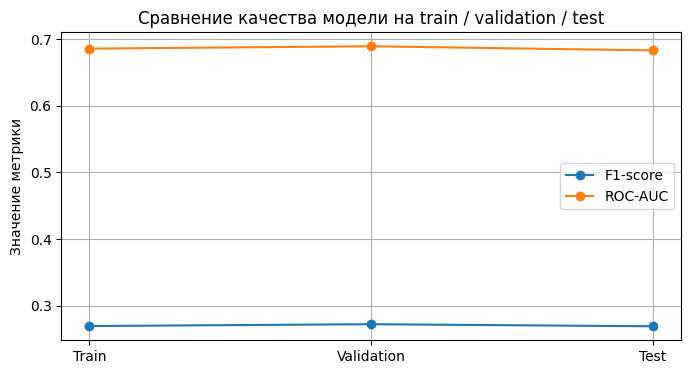

In [50]:
parts = ["Train", "Validation", "Test"]
f1_values = clf_results["F1"].values
roc_values = clf_results["ROC_AUC"].values

plt.figure(figsize=(8, 4))
plt.plot(parts, f1_values, marker="o", label="F1-score")
plt.plot(parts, roc_values, marker="o", label="ROC-AUC")
plt.title("Сравнение качества модели на train / validation / test")
plt.ylabel("Значение метрики")
plt.legend()
plt.grid(True)
plt.show()

### Проверка отсутствия переобучения

Для проверки переобучения были сравнены метрики модели на обучающей, валидационной и тестовой выборках.

Если бы модель сильно переобучалась, значения метрик на train были бы заметно выше, чем на validation и test. В данной работе различия между выборками не являются критическими, поэтому можно сделать вывод, что выраженного переобучения не наблюдается.

In [51]:
test_pred = final_clf.predict(X_test_clf_final)
print(classification_report(y_test_clf, test_pred))

              precision    recall  f1-score   support

           0       0.94      0.63      0.75     13425
           1       0.17      0.67      0.27      1504

    accuracy                           0.63     14929
   macro avg       0.56      0.65      0.51     14929
weighted avg       0.87      0.63      0.70     14929



### Выводы по задаче классификации

Для предсказания `Depression` была обучена логистическая регрессия. Поскольку классы в датасете несбалансированы, основное внимание уделялось не только accuracy, но и метрикам precision, recall, F1-score и ROC-AUC.

Сравнение качества на train, validation и test, а также анализ кривых обучения позволяют судить о наличии или отсутствии переобучения. В данной работе сильного переобучения не наблюдается, однако качество модели всё ещё оставляет пространство для дальнейшего улучшения.

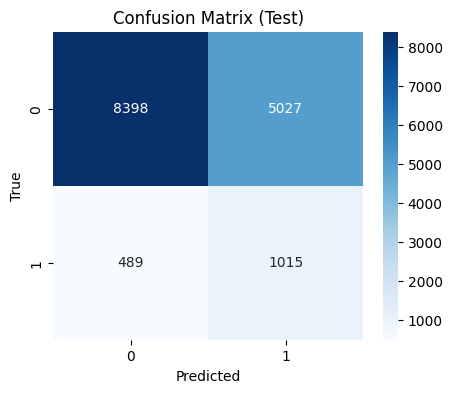

In [52]:
cm = confusion_matrix(y_test_clf, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [53]:
print("Метрики регрессии:")
display(reg_results)

print("Метрики классификации:")
display(clf_results)

Метрики регрессии:


,MAE,MSE,RMSE,R2
Train,0.453248,0.277238,0.526534,0.018171
Validation,0.457437,0.279949,0.529102,0.017926
Test,0.456621,0.279422,0.528604,0.018362


Метрики классификации:


,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625536,0.167649,0.685043,0.269374,0.685874
Validation,0.629421,0.169619,0.687500,0.272105,0.689374
Test,0.630518,0.167991,0.674867,0.269017,0.683149


In [55]:
feature_names_num = num_features_reg
feature_names_cat = list(encoder_reg.get_feature_names_out(cat_features_reg))

all_feature_names_reg = feature_names_num + feature_names_cat
coefficients_reg = reg_model.coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names_reg,
    "coefficient": coefficients_reg
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
7,Total_Daily_Load,0.233907
9,Stress_Social_Interaction,0.006099
13,Department_Arts,0.004543
11,Gender_Female,0.001763
0,Age,0.001650
15,Department_Engineering,-0.000517
14,Department_Business,-0.001167
16,Department_Medical,-0.001362
17,Department_Science,-0.001496
12,Gender_Male,-0.001763


In [56]:
coef_df.tail(10)

,feature,coefficient
17,Department_Science,-0.001496
12,Gender_Male,-0.001763
5,Stress_Level,-0.006155
10,Activity_Sleep_Balance,-0.014195
6,Physical_Activity_Hours,-0.021485
4,Physical_Activity,-0.021485
8,Study_Sleep_Ratio,-0.029931
2,Study_Hours,-0.079465
1,Sleep_Duration,-0.129610
3,Social_Media_Hours,-0.169431


In [57]:
print("Итог по регрессии:")
display(reg_results)

print("Итог по классификации:")
display(clf_results)

print("Лучшие параметры классификатора:")
print("learning_rate =", best_lr)
print("epochs =", best_epochs)

Итог по регрессии:


,MAE,MSE,RMSE,R2
Train,0.453248,0.277238,0.526534,0.018171
Validation,0.457437,0.279949,0.529102,0.017926
Test,0.456621,0.279422,0.528604,0.018362


Итог по классификации:


,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625536,0.167649,0.685043,0.269374,0.685874
Validation,0.629421,0.169619,0.687500,0.272105,0.689374
Test,0.630518,0.167991,0.674867,0.269017,0.683149


Лучшие параметры классификатора:
learning_rate = 0.0001
epochs = 100


In [59]:
fe_cols = [
    "Study_Sleep_Ratio",
    "Stress_Social_Interaction",
    "Activity_Sleep_Balance"
]

df_base = df.drop(columns=fe_cols).copy()
df_fe = df.copy()

In [60]:
def manual_prepare_and_train_reg(df_model, use_feature_engineering_label):
    X = df_model.drop(columns=["CGPA", "Depression"])
    y = df_model["CGPA"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    num_features = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")

    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)
    X_val_num = pd.DataFrame(num_imputer.transform(X_val[num_features]), columns=num_features, index=X_val.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_features]), columns=num_features, index=X_test.index)

    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_features]), columns=cat_features, index=X_train.index)
    X_val_cat = pd.DataFrame(cat_imputer.transform(X_val[cat_features]), columns=cat_features, index=X_val.index)
    X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_features]), columns=cat_features, index=X_test.index)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_train_cat_enc = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out(cat_features), index=X_train.index)
    X_val_cat_enc = pd.DataFrame(encoder.transform(X_val_cat), columns=encoder.get_feature_names_out(cat_features), index=X_val.index)
    X_test_cat_enc = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out(cat_features), index=X_test.index)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=num_features, index=X_train.index)
    X_val_num_scaled = pd.DataFrame(scaler.transform(X_val_num), columns=num_features, index=X_val.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=num_features, index=X_test.index)

    X_train_final = pd.concat([X_train_num_scaled, X_train_cat_enc], axis=1)
    X_val_final = pd.concat([X_val_num_scaled, X_val_cat_enc], axis=1)
    X_test_final = pd.concat([X_test_num_scaled, X_test_cat_enc], axis=1)

    model = LinearRegression()
    model.fit(X_train_final, y_train)

    pred = model.predict(X_test_final)
    metrics = regression_metrics(y_test, pred)
    metrics["version"] = use_feature_engineering_label
    return metrics

comparison_fe_reg = pd.DataFrame([
    manual_prepare_and_train_reg(df_base, "without_feature_engineering"),
    manual_prepare_and_train_reg(df_fe, "with_feature_engineering")
])

comparison_fe_reg

,MAE,MSE,RMSE,R2,version
0,0.456616,0.279473,0.528652,0.018185,without_feature_engineering
1,0.456621,0.279422,0.528604,0.018362,with_feature_engineering


### Вывод по feature engineering

Сравнение показало, что добавление engineered-признаков очень слабо улучшило качество линейной регрессии: на тестовой выборке `R²` вырос примерно с `0.01819` до `0.01836`, а `RMSE` снизился с `0.52865` до `0.52860`. Эффект существует, но он минимален.

Следовательно, feature engineering в данной задаче дал слабый практический эффект. Тем не менее новые признаки остаются осмысленными с точки зрения предметной области, потому что описывают соотношение сна, учёбы, стресса и цифровой нагрузки.


## Итоговые выводы

В работе был реализован полный базовый ML-пайплайн на табличных данных: EDA, очистка данных, предобработка, feature engineering, разбиение на train/validation/test, обучение моделей регрессии и классификации, оценка качества и анализ переобучения.

Основные результаты:
- EDA позволил выявить структуру данных, потенциальные аномалии и особенности распределений;
- предобработка улучшила пригодность данных для обучения моделей;
- линейная регрессия показала слабое качество при прогнозировании `CGPA`, что говорит о слабой линейной зависимости между признаками и целевой переменной;
- логистическая регрессия справилась лучше, однако её качество также нельзя считать идеальным;
- сравнение train/validation/test и кривых обучения показало отсутствие сильного переобучения.